# REST CLIENT

## Imports and constants

In [ ]:
import requests
import matplotlib.pyplot as plt
import datetime
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# Put here yout Deepnote host URL or localhost if you are running the server locally
host = "https://70b36598-46ed-4ae6-8e28-ad59f7ac4c24.deepnoteproject.com"

## Check server status

In [2]:
response = requests.get(host + '/status')
if response.status_code == 200:
    status = response.json()['status']
    print(f'The server is {status}.')
else:
    print('The server is offline.')
    exit()

The server is online.


## Add your RPI sensor node using POST /sensors

In [3]:
mac_address = '0xe45f01d8f381'

payload = {'mac_address': mac_address}
# Specify the request body with "json" argument of the post method.
response = requests.post(host + '/sensors', json=payload)

# Check the response code. The expected value is 200.
if response.status_code == 200:
    print('Sensor timeseries added.')
else:
    print(response.status_code, response.reason)


409 Conflict


## Retrieve the 10 most recent temperature and humidity samples collected by your RPI using the endpoint implemented in Section 2.1.

In [4]:
response = requests.get(host + f'/data/{mac_address}?count=10')
# Check the response code. The expected value is 200.
if response.status_code == 200:
    data = response.json()
    print(data)
else:
    data = None
    print(response.status_code, response.reason)

{'mac_address': '0xe45f01d8f381', 'timestamp': [1769772472870, 1769772467363, 1769772462108, 1769772456853, 1769772451599, 1769772446344, 1769772441089, 1769772435834, 1769772430579, 1769772425324], 'temperature': [22.0, 21.0, 21.0, 21.0, 21.0, 21.0, 21.0, 21.0, 21.0, 21.0], 'humidity': [66.0, 55.0, 53.0, 54.0, 53.0, 49.0, 45.0, 45.0, 45.0, 45.0]}


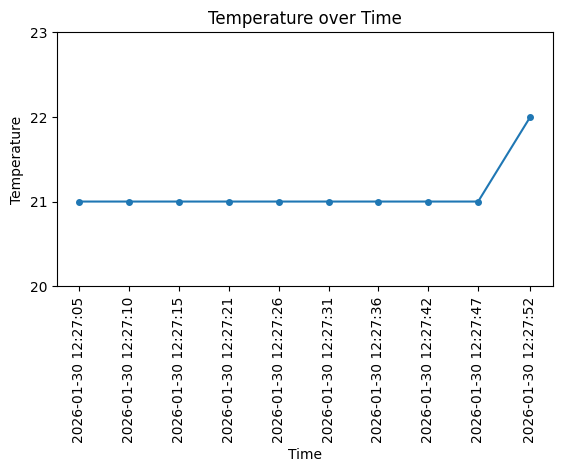

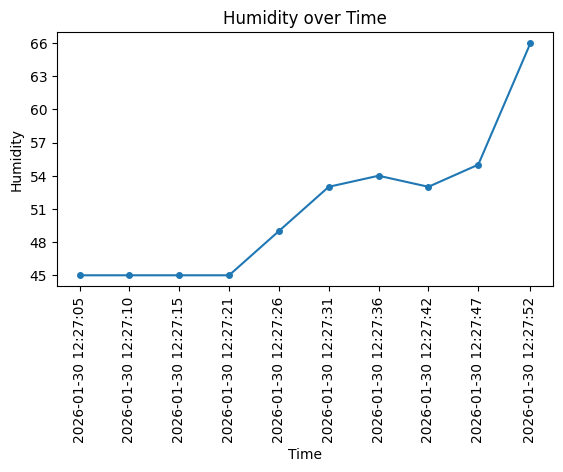

In [ ]:
# plot the data if available
if data is not None:
    # Convert timestamps from milliseconds to datetime
    x = [datetime.datetime.fromtimestamp(ts / 1000) for ts in data["timestamp"]]
    temperature = data["temperature"]
    humidity = data["humidity"]

    # Plot Temperature
    plt.figure()
    plt.plot(x, temperature, marker='o', markersize=4)
    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.title("Temperature over Time")

    temp_max = max(temperature)
    temp_min = min(temperature)
    plt.ylim(temp_min - 1, temp_max + 1)

    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xticks(x)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M:%S"))
    plt.xticks(rotation=90)
    plt.subplots_adjust(bottom=0.35)

    plt.show()
    plt.close()

    # Plot Humidity 
    plt.figure()
    plt.plot(x, humidity, marker='o', markersize=4)
    plt.xlabel("Time")
    plt.ylabel("Humidity")
    plt.title("Humidity over Time")

    hum_max = max(humidity)
    hum_min = min(humidity)
    plt.ylim(hum_min - 1, hum_max + 1)

    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xticks(x)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M:%S"))
    plt.xticks(rotation=90)
    plt.subplots_adjust(bottom=0.35)

    plt.show()
    plt.close()